Libraries and data import

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Data Explotation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #Visualization
import seaborn as sns #Advanced Visualization
%matplotlib inline

# Data modelling libraries
from sklearn.impute import SimpleImputer
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier 
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

from sklearn.metrics import classification_report, confusion_matrix
import itertools
from sklearn.metrics import f1_score

In [2]:
#Loading data 
fraud = pd.read_csv("Fraud Detection Dataset.csv")
fraud.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [3]:
fraud['User_ID'].nunique()

4000

In [4]:
fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

In [5]:
fraud.describe()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.000000,48480.000000,48448.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,3005.110176,2996.249784,11.488400,1.995725,60.033902,7.495588,0.049216
std,1153.121107,5043.932555,6.922954,1.415150,34.384131,4.020080,0.216320
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1270.552500,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2996.000000,2524.100000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4006.000000,3787.240000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [6]:
fraud.isnull().sum()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

In [7]:
missing_perc = fraud.isnull().sum() / len(fraud) * 100
print(missing_perc)

Transaction_ID                      0.000000
User_ID                             0.000000
Transaction_Amount                  4.941176
Transaction_Type                    0.000000
Time_of_Transaction                 5.003922
Device_Used                         4.849020
Location                            4.994118
Previous_Fraudulent_Transactions    0.000000
Account_Age                         0.000000
Number_of_Transactions_Last_24H     0.000000
Payment_Method                      4.841176
Fraudulent                          0.000000
dtype: float64


In [8]:
#drop columns Transaction_ID
fraud = fraud.drop(columns=['Transaction_ID', 'User_ID'])

In [9]:
# view the numeric col 
numeric_col = fraud.select_dtypes(include=['int64', 'float64']).columns
print(numeric_col)

Index(['Transaction_Amount', 'Time_of_Transaction',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H', 'Fraudulent'],
      dtype='object')


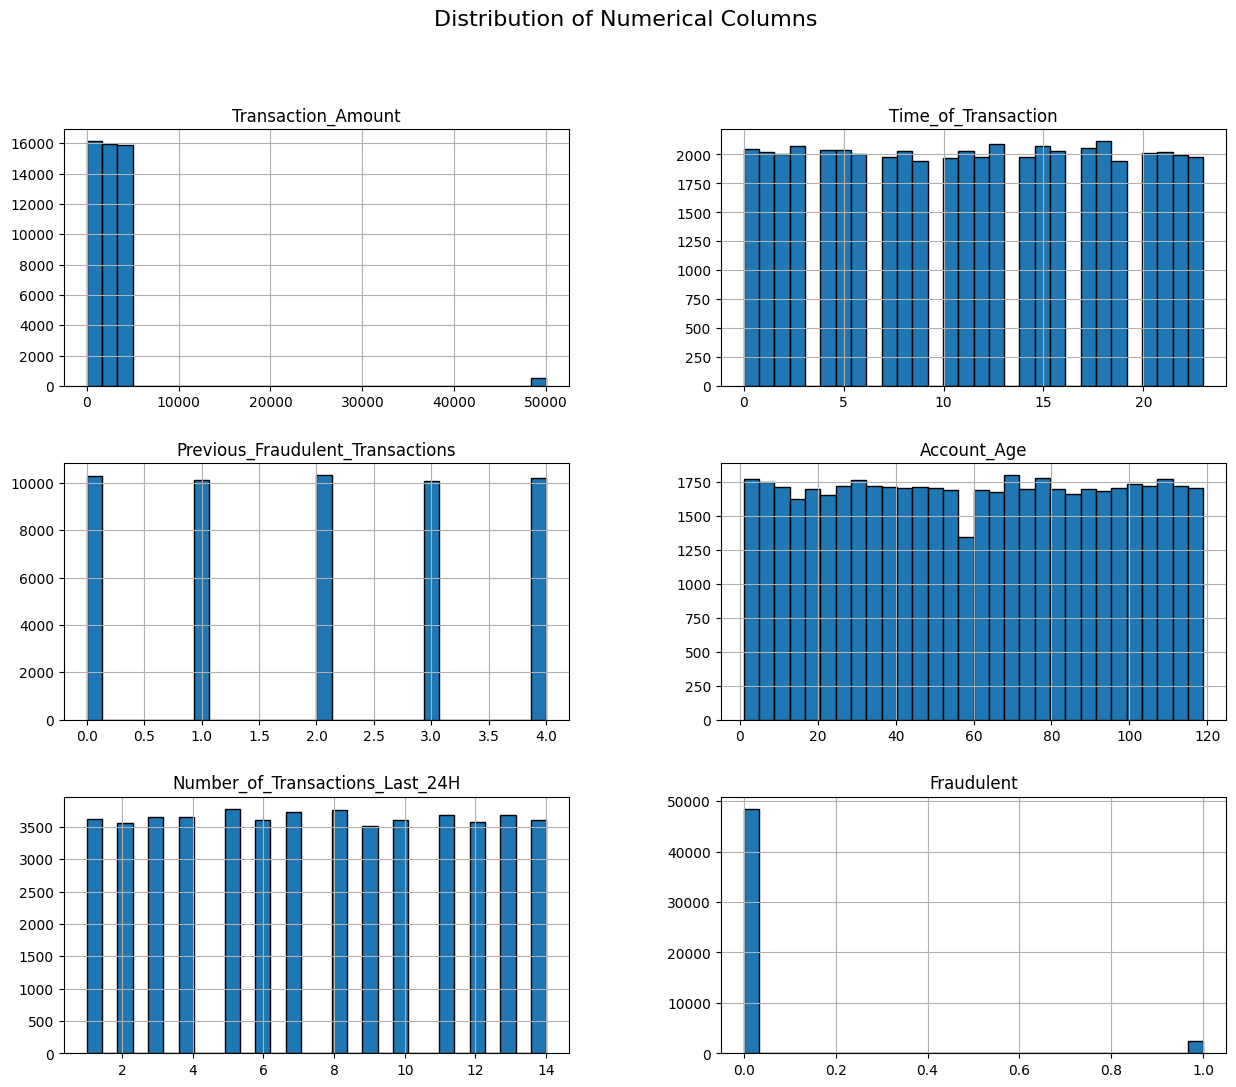

In [10]:
num_cols = fraud.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms
fraud[num_cols].hist(figsize=(15, 12), bins=30, edgecolor="black")
plt.suptitle("Distribution of Numerical Columns", fontsize=16)
plt.show()

In [ ]:
# for col in numeric_col:
#     plt.Figure()
#     sns.histplot(fraud[col], kde=True)
#     plt.title(f'Distribution of {col}')
#     plt.show()

Analyze transaction behavior

In [11]:
fraud['Fraudulent'].value_counts()

Fraudulent
0    48490
1     2510
Name: count, dtype: int64

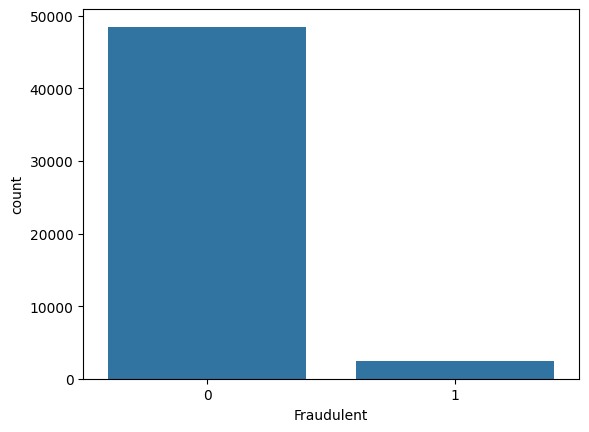

In [12]:
sns.countplot(x='Fraudulent', data=fraud)
plt.show()

In [13]:
#Fraud by amount
fraud.groupby('Fraudulent')['Transaction_Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Fraudulent,,,,,,,,
0,46095.0,2989.931309,5010.290069,5.03,1272.255,2524.39,3789.59,49997.8
1,2385.0,3118.367245,5654.749402,14.31,1222.260,2516.01,3738.62,49997.8


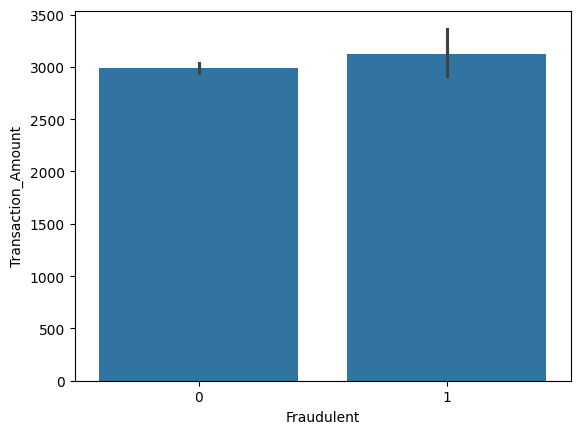

In [14]:

sns.barplot(x='Fraudulent', y='Transaction_Amount', data=fraud)
plt.show()

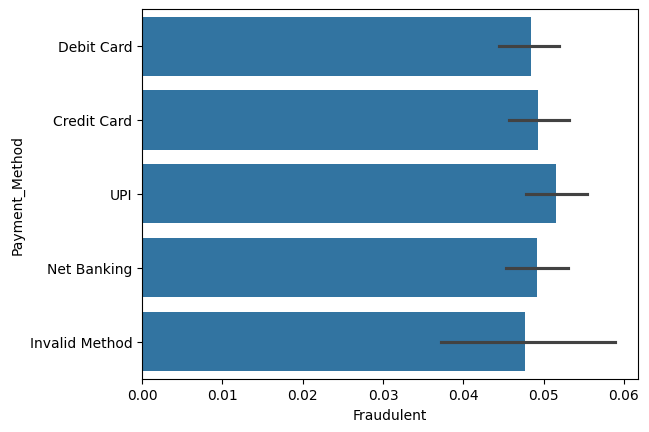

In [15]:
# Fraud by payment type
sns.barplot(x='Fraudulent', y='Payment_Method', data=fraud)
plt.show()

In [16]:
# Fraud by time of trasaction
fraud_by_hour = fraud[fraud['Fraudulent'] == 1]['Time_of_Transaction'].value_counts().sort_index()

print(fraud_by_hour)

Time_of_Transaction
0.0      94
1.0      97
2.0     102
3.0      96
4.0      99
5.0      91
6.0     102
7.0     107
8.0      95
9.0      84
10.0     92
11.0     95
12.0     90
13.0     96
14.0     89
15.0    119
16.0     98
17.0    107
18.0    109
19.0     93
20.0    115
21.0     87
22.0    115
23.0    104
Name: count, dtype: int64


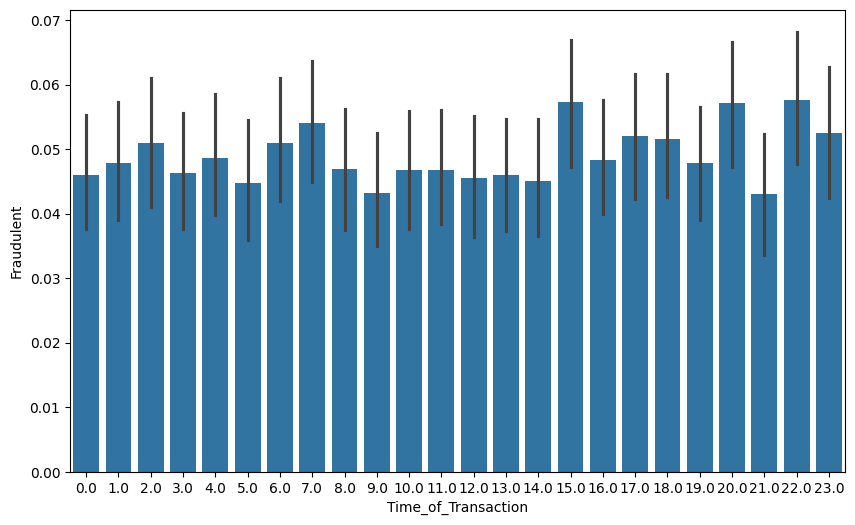

In [17]:
# Fraud by time
plt.figure(figsize=(10,6))
sns.barplot(y='Fraudulent', x='Time_of_Transaction', data=fraud)
plt.show()

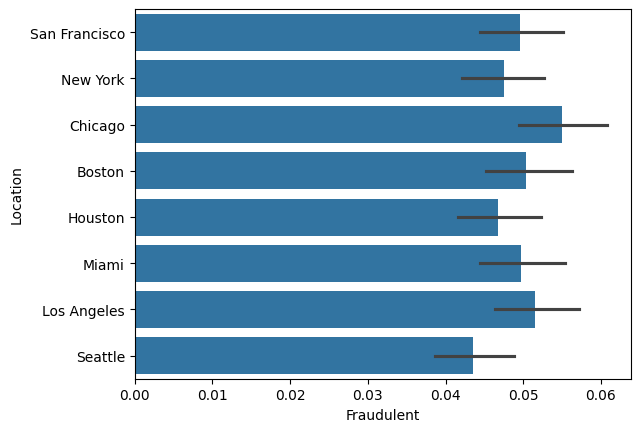

In [18]:
# Fraud by location
#plt.figure(figsize=(10,6))
sns.barplot(x='Fraudulent', y='Location', data=fraud)
plt.show()

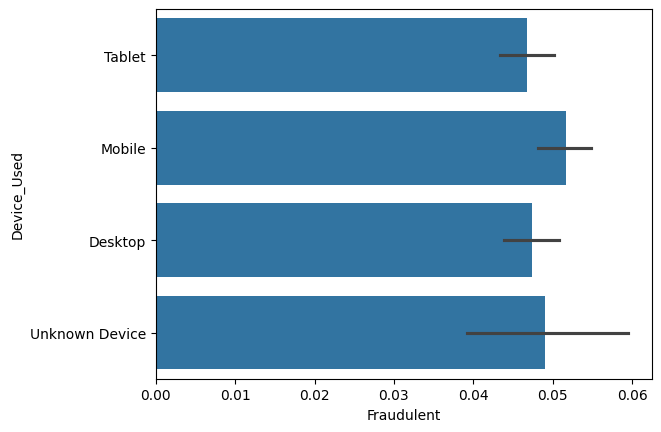

In [19]:
# Fraud by Device
#plt.figure(figsize=(10,6))
sns.barplot(x='Fraudulent', y='Device_Used', data=fraud)
plt.show()

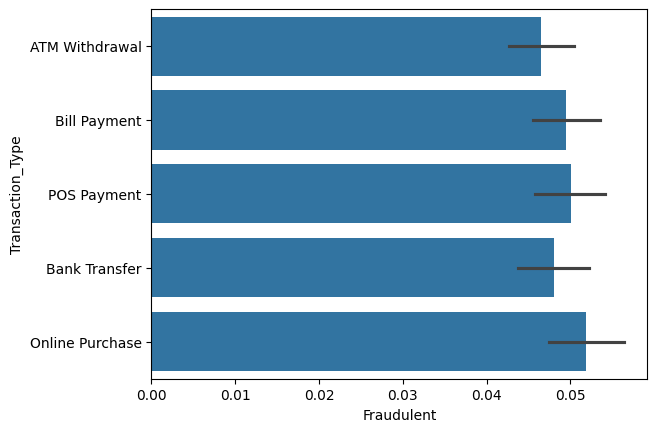

In [20]:
# Fraud by Type

sns.barplot(x='Fraudulent', y='Transaction_Type', data=fraud)
plt.show()

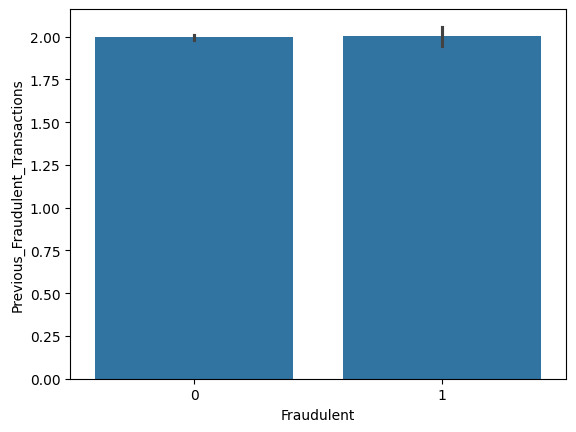

In [21]:
# Fraud by Type

sns.barplot(x='Fraudulent', y='Previous_Fraudulent_Transactions', data=fraud)
plt.show()

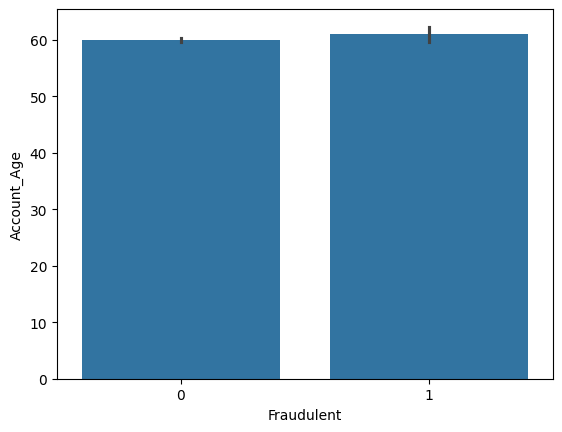

In [22]:
sns.barplot(x='Fraudulent', y='Account_Age', data=fraud)
plt.show()

In [12]:
fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_Amount                48480 non-null  float64
 1   Transaction_Type                  51000 non-null  object 
 2   Time_of_Transaction               48448 non-null  float64
 3   Device_Used                       48527 non-null  object 
 4   Location                          48453 non-null  object 
 5   Previous_Fraudulent_Transactions  51000 non-null  int64  
 6   Account_Age                       51000 non-null  int64  
 7   Number_of_Transactions_Last_24H   51000 non-null  int64  
 8   Payment_Method                    48531 non-null  object 
 9   Fraudulent                        51000 non-null  int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 3.9+ MB


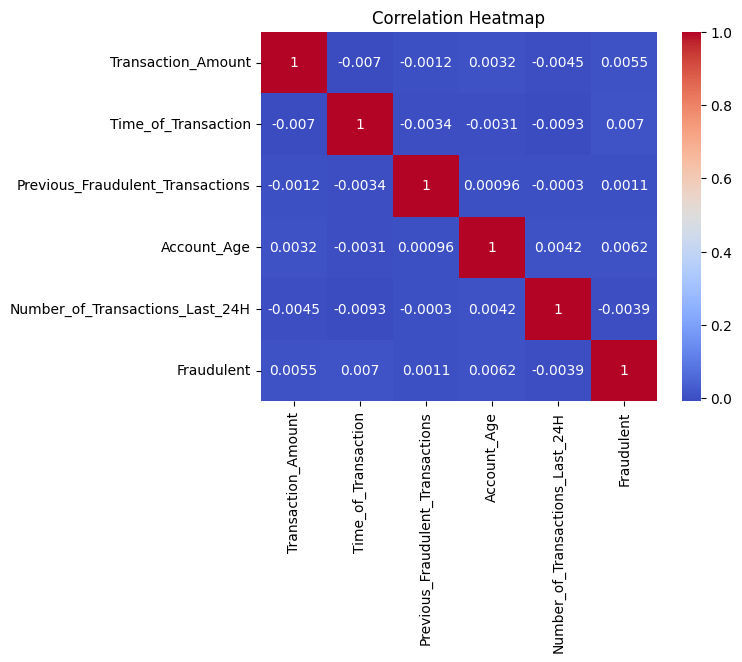

In [13]:
sns.heatmap(fraud.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

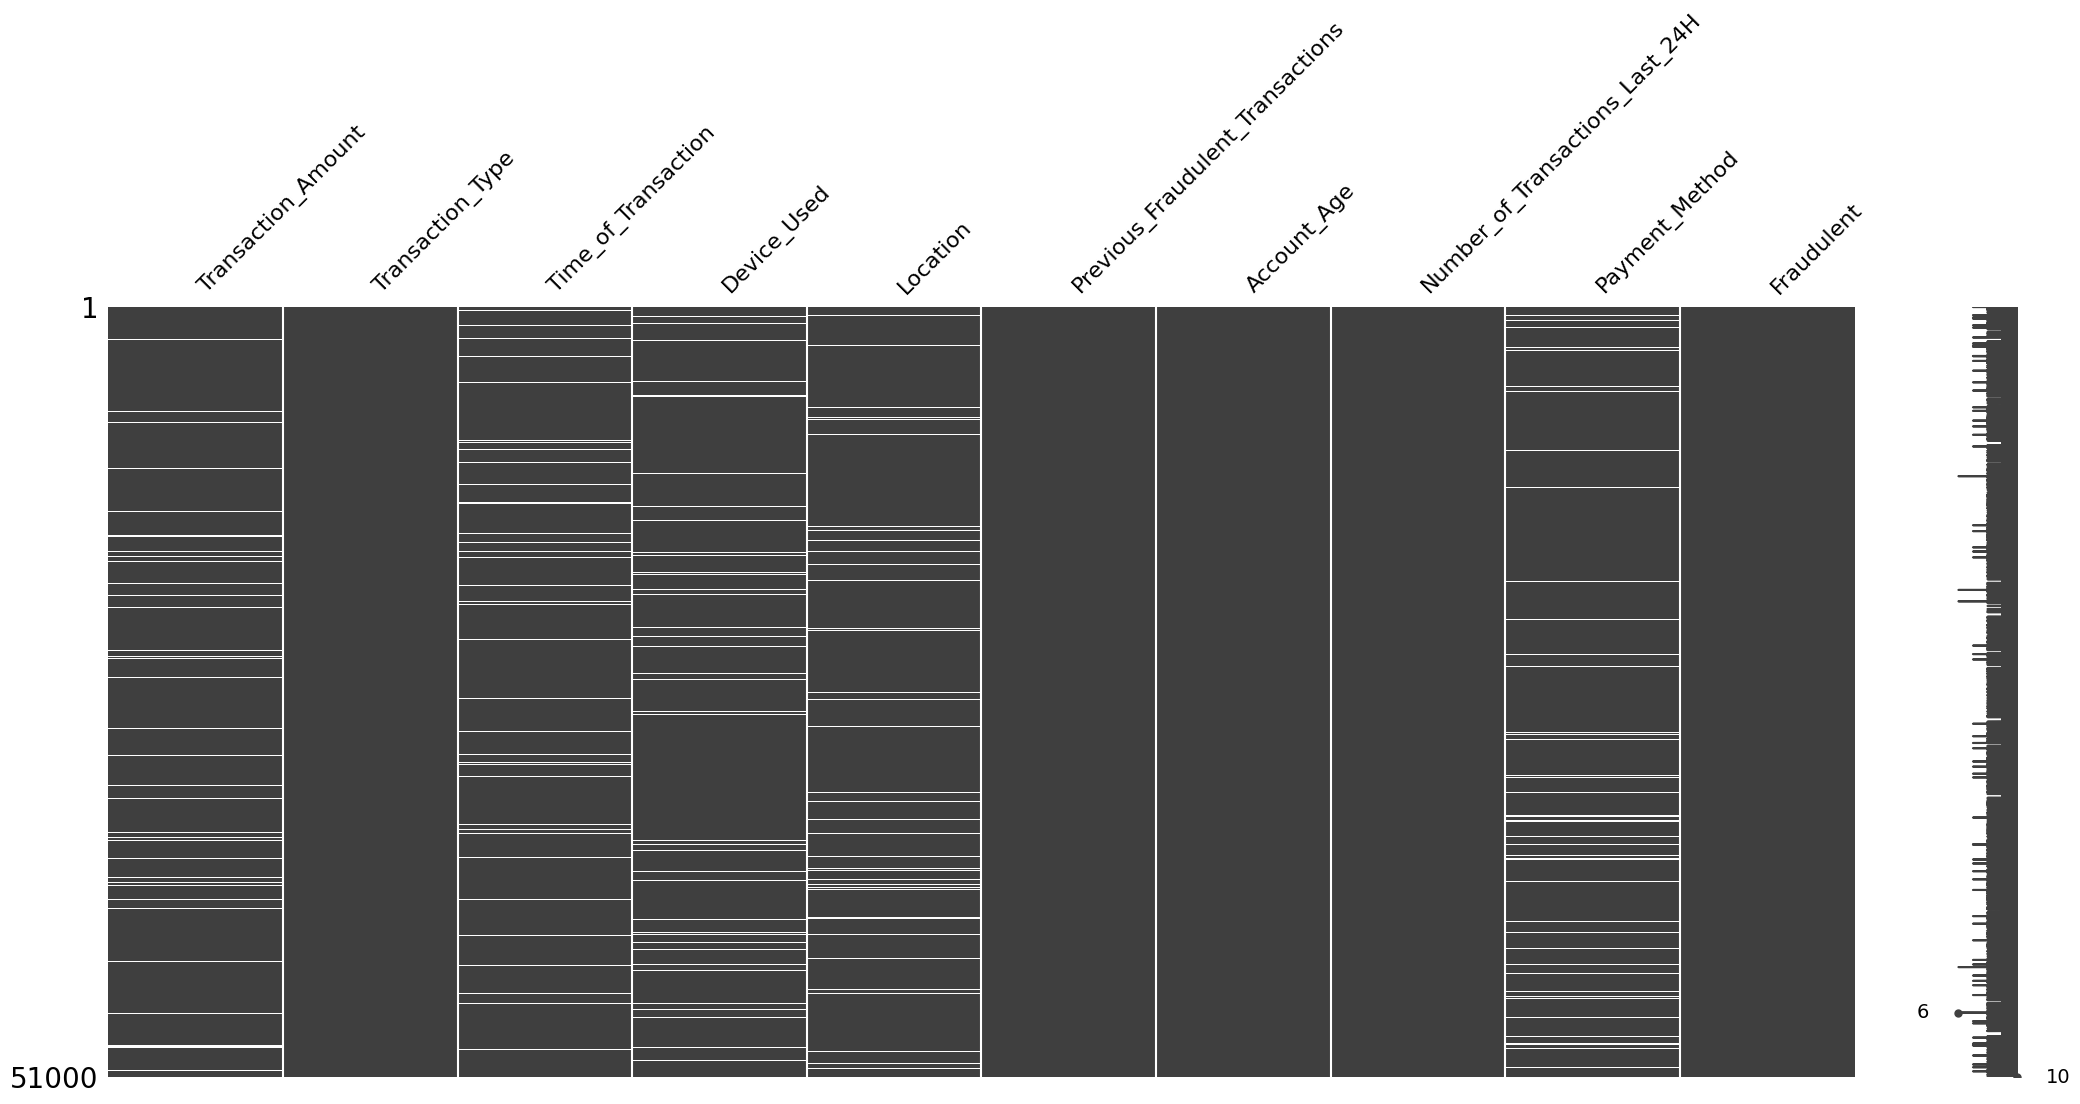

In [12]:
import missingno as msno
msno.matrix(fraud)
plt.show()

MIssing values

In [26]:
missing_perc = fraud.isnull().sum() / len(fraud) * 100
print(missing_perc)

Transaction_Amount                  4.941176
Transaction_Type                    0.000000
Time_of_Transaction                 5.003922
Device_Used                         4.849020
Location                            4.994118
Previous_Fraudulent_Transactions    0.000000
Account_Age                         0.000000
Number_of_Transactions_Last_24H     0.000000
Payment_Method                      4.841176
Fraudulent                          0.000000
dtype: float64


In [13]:
fraud2 = fraud.copy()

In [14]:
fraud2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_Amount                48480 non-null  float64
 1   Transaction_Type                  51000 non-null  object 
 2   Time_of_Transaction               48448 non-null  float64
 3   Device_Used                       48527 non-null  object 
 4   Location                          48453 non-null  object 
 5   Previous_Fraudulent_Transactions  51000 non-null  int64  
 6   Account_Age                       51000 non-null  int64  
 7   Number_of_Transactions_Last_24H   51000 non-null  int64  
 8   Payment_Method                    48531 non-null  object 
 9   Fraudulent                        51000 non-null  int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 3.9+ MB


In [15]:
fraud2['Transaction_Amount'] = fraud2['Transaction_Amount'].fillna(fraud2['Transaction_Amount'].mean())
fraud2['Time_of_Transaction'] = fraud2['Time_of_Transaction'].fillna(fraud2['Time_of_Transaction'].mean())

fraud2['Device_Used'] = fraud2['Device_Used'].fillna(fraud2['Device_Used'].mode()[0])
fraud2['Location'] = fraud2['Location'].fillna(fraud2['Location'].mode()[0])
fraud2['Payment_Method'] = fraud2['Payment_Method'].fillna(fraud2['Payment_Method'].mode()[0])

In [16]:
fraud2.isnull().sum()

Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64

#### Detect Outliers with Boxplot

In [18]:
fraud_5000 = fraud2[(fraud2['Transaction_Amount'] >= 5000)]
fraud_5000.shape[0]



508

In [19]:
fraud_less_5000 = fraud2[(fraud2['Transaction_Amount'] < 5000)]
fraud_less_5000.shape[0]


50492

In [20]:
fraud_5000.head(2)

,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
166,49997.8,POS Payment,3.0,Desktop,Miami,3,108,8,UPI,0
236,49997.8,ATM Withdrawal,3.0,Tablet,Boston,3,103,6,UPI,0


In [21]:
fraud_5000['Fraudulent'].value_counts(normalize=True) * 100

Fraudulent
0    93.700787
1     6.299213
Name: proportion, dtype: float64

In [22]:
fraud2['Fraudulent'].value_counts(normalize=True) * 100

Fraudulent
0    95.078431
1     4.921569
Name: proportion, dtype: float64

In [23]:
fraud_less_5000['Fraudulent'].value_counts(normalize=True) * 100

Fraudulent
0    95.092292
1     4.907708
Name: proportion, dtype: float64

In [24]:
before = fraud2.shape[0]
print(before)

51000


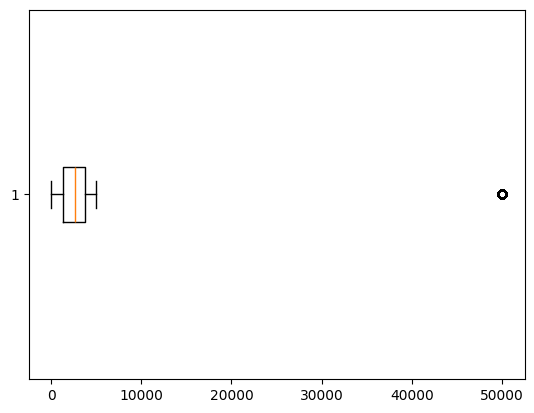

In [25]:
plt.boxplot(fraud2['Transaction_Amount'], vert=False)
plt.show()

In [ ]:
# compute Threshold

# threshold = fraud2['Transaction_Amount'].quantile(0.9998)
# fraud2 = fraud2[fraud2['Transaction_Amount'] < threshold]

In [ ]:
# removed = before - threshold

# print("Rows removed:", removed)

Rows removed: 1002.1999999999971


### ANALYZE HIGH AMOUNT

In [26]:
# High amount + late-night transaction
fraud2['high_morn_flag'] = (
    (fraud2['Transaction_Amount'] > 5000) &
    (fraud2['Time_of_Transaction'].isin([0,1,2,3,4,5,6,7,8]))
).astype(int)

In [27]:
print(fraud2['high_morn_flag'].mean() * 100)

0.3823529411764706


In [28]:
fraud2['high_night_flag'] = (
    (fraud2['Transaction_Amount'] > 5000) &
    (fraud2['Time_of_Transaction'].isin([15, 16, 17, 18, 19, 20, 21, 22, 23]))
).astype(int)

In [29]:
print(fraud2['high_night_flag'].mean() * 100)

0.3568627450980392


In [30]:
#payment methods check

fraud_5000.groupby('Payment_Method')['Fraudulent'].mean() *100

Payment_Method
Credit Card        8.800000
Debit Card         4.032258
Invalid Method    23.529412
Net Banking        4.901961
UPI                5.000000
Name: Fraudulent, dtype: float64

In [22]:
fraud.groupby('Payment_Method')['Fraudulent'].mean() *100

Payment_Method
Credit Card       4.928731
Debit Card        4.846636
Invalid Method    4.771242
Net Banking       4.920281
UPI               5.148482
Name: Fraudulent, dtype: float64

In [23]:
#device check

fraud_5000.groupby('Device_Used')['Fraudulent'].mean() * 100

Device_Used
Desktop            4.519774
Mobile             7.228916
Tablet             5.960265
Unknown Device    21.428571
Name: Fraudulent, dtype: float64

In [24]:
fraud2.groupby('Device_Used')['Fraudulent'].mean() * 100

Device_Used
Desktop           4.926648
Mobile            5.162034
Tablet            4.676674
Unknown Device    4.901961
Name: Fraudulent, dtype: float64

In [25]:
fraud_5000.groupby('Location')['Fraudulent'].mean() *100

Location
Boston           11.842105
Chicago           8.928571
Houston           3.278689
Los Angeles       5.970149
Miami             4.838710
New York          4.615385
San Francisco     7.692308
Seattle           2.898551
Name: Fraudulent, dtype: float64

In [26]:
fraud2.groupby('Location')['Fraudulent'].mean() *100

Location
Boston           4.979301
Chicago          5.501565
Houston          4.675841
Los Angeles      5.156354
Miami            4.974128
New York         4.746318
San Francisco    4.962406
Seattle          4.357798
Name: Fraudulent, dtype: float64

In [17]:
fraud2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_Amount                51000 non-null  float64
 1   Transaction_Type                  51000 non-null  object 
 2   Time_of_Transaction               51000 non-null  float64
 3   Device_Used                       51000 non-null  object 
 4   Location                          51000 non-null  object 
 5   Previous_Fraudulent_Transactions  51000 non-null  int64  
 6   Account_Age                       51000 non-null  int64  
 7   Number_of_Transactions_Last_24H   51000 non-null  int64  
 8   Payment_Method                    51000 non-null  object 
 9   Fraudulent                        51000 non-null  int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 3.9+ MB


#Encoding

In [ ]:
# cols = Loan_renamed.select_dtypes(include='object').columns
# Loan_renamed[cols] = Loan_renamed[cols].astype('string')

- Tran Type: frequncy
- Device Used: Nominal
- Location: frequency
- Payment: frequency

In [18]:
fraud3 = fraud2.copy()

In [24]:
object_cols = fraud3.select_dtypes(include='object').columns

fraud3[object_cols] = fraud3[object_cols].astype('string')

In [27]:
fraud3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_Amount                51000 non-null  float64
 1   Time_of_Transaction               51000 non-null  float64
 2   Previous_Fraudulent_Transactions  51000 non-null  int64  
 3   Account_Age                       51000 non-null  int64  
 4   Number_of_Transactions_Last_24H   51000 non-null  int64  
 5   Fraudulent                        51000 non-null  int64  
 6   Device_Used_Mobile                51000 non-null  bool   
 7   Device_Used_Tablet                51000 non-null  bool   
 8   Device_Used_Unknown Device        51000 non-null  bool   
 9   Transaction_Type_freq             51000 non-null  Int64  
 10  Location_freq                     51000 non-null  Int64  
 11  Payment_Method_freq               51000 non-null  Int64  
dtypes: I

In [21]:
# ENCODING
# Categorical col 

# norminal_col = [col for col in fraud2.columns if fraud2[col].dtypes == 'object']
# print(norminal_col)

nominal_col = ['Device_Used']
frequency_col = ['Transaction_Type', 'Location', 'Payment_Method']




In [26]:
# Frequency Encoding
for col in frequency_col:
    freq = fraud3[col].value_counts()

    # Create encoded column
    fraud3[col + '_freq'] = fraud3[col].map(freq)

    #fraud3[col] = fraud3[col].map(freq)
    # Drop original categorical columns
fraud3.drop(frequency_col, axis=1, inplace=True)


In [22]:
# One-hot encoding

fraud3 = pd.get_dummies(fraud2, columns=nominal_col, drop_first=True)

# fraud3 = pd.get_dummies(fraud2, columns=cat_col, drop_first=True)
# fraud3.head()

In [28]:
fraud3['Fraudulent'].value_counts(normalize=True) * 100

Fraudulent
0    95.078431
1     4.921569
Name: proportion, dtype: float64

In [29]:
fraud3.head()

,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent,Device_Used_Mobile,Device_Used_Tablet,Device_Used_Unknown Device,Transaction_Type_freq,Location_freq,Payment_Method_freq
0,1292.76,16.0000,0,119,13,0,False,True,False,10164,5985,11802
1,1554.58,13.0000,4,79,3,0,True,False,False,10164,6110,11646
2,2395.02,11.4884,3,115,9,0,True,False,False,10164,8696,14356
3,100.10,15.0000,4,3,4,0,False,False,False,10340,6071,14356
4,1490.50,19.0000,2,57,7,0,True,False,False,10126,5985,11646


In [30]:
fraud3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_Amount                51000 non-null  float64
 1   Time_of_Transaction               51000 non-null  float64
 2   Previous_Fraudulent_Transactions  51000 non-null  int64  
 3   Account_Age                       51000 non-null  int64  
 4   Number_of_Transactions_Last_24H   51000 non-null  int64  
 5   Fraudulent                        51000 non-null  int64  
 6   Device_Used_Mobile                51000 non-null  bool   
 7   Device_Used_Tablet                51000 non-null  bool   
 8   Device_Used_Unknown Device        51000 non-null  bool   
 9   Transaction_Type_freq             51000 non-null  Int64  
 10  Location_freq                     51000 non-null  Int64  
 11  Payment_Method_freq               51000 non-null  Int64  
dtypes: I

Check imbalance

In [31]:
fraud3['Fraudulent'].value_counts(normalize=True) * 100

Fraudulent
0    95.078431
1     4.921569
Name: proportion, dtype: float64

In [32]:
# # Features and target
X = fraud3.drop(columns=['Fraudulent'])
y = fraud3['Fraudulent']

In [33]:
# Convert all features to float
X = X.astype(float)

### Split data

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#drop columns Transaction_ID
fraud3 = fraud3.drop(columns=['high_morn_flag', 'high_night_flag'])

### Feature Scaling

In [33]:

num_cols = ['Transaction_Amount', 'Time_of_Transaction', 'Transaction_Type_freq',
       'Previous_Fraudulent_Transactions', 'Account_Age', 'Location_freq', 'Payment_Method_freq',
       'Number_of_Transactions_Last_24H']

# Columns to scale
scale_cols = ['Transaction_Amount', 'Time_of_Transaction', 'Transaction_Type_freq',
       'Previous_Fraudulent_Transactions', 'Account_Age', 'Location_freq', 'Payment_Method_freq',
       'Number_of_Transactions_Last_24H']


In [34]:
from sklearn.preprocessing import StandardScaler

# Fit scaler ONLY on training data
scaler = StandardScaler()

# Scale selected columns
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Use same scaler on test data
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [35]:
# Scale first
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Then SMOTE
smote = SMOTE()
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [119]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

In [36]:
# Print dataset shapes
print("Training dataset shape:", X_train.shape, y_train.shape)
print("Test dataset shape:", X_test.shape, y_test.shape)

Training dataset shape: (40800, 11) (40800,)
Test dataset shape: (10200, 11) (10200,)


In [121]:
from imblearn.over_sampling import SMOTE

# smote = SMOTE()
# X_resampled, y_resampled = smote.fit_resample(X, y)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [61]:
print("Test dataset shape:", X_resampled.shape, y_resampled.shape)

NameError: name 'X_resampled' is not defined

Model Selection

In [37]:
from sklearn.linear_model import LogisticRegression
# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [39]:
models = {
    'Logistic Regression':
        LogisticRegression(class_weight='balanced'),

    'Random Forest':
        RandomForestClassifier(class_weight='balanced'),


}

In [40]:
from sklearn.metrics import classification_report

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(name)

    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.53      0.68      9698
           1       0.05      0.47      0.09       502

    accuracy                           0.52     10200
   macro avg       0.50      0.50      0.38     10200
weighted avg       0.91      0.52      0.65     10200

Random Forest
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9698
           1       1.00      0.02      0.05       502

    accuracy                           0.95     10200
   macro avg       0.98      0.51      0.51     10200
weighted avg       0.95      0.95      0.93     10200



Improve Random Forest

In [126]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [127]:
# Use class_weight='balanced'
RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [128]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder,LabelBinarizer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as make_pipeline_imb

import warnings
warnings.filterwarnings('ignore')

In [129]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'K-Nearest Neighbors': make_pipeline_imb(SMOTE(random_state=42), KNeighborsClassifier()),
    'Support Vector Machine': make_pipeline_imb(SMOTE(random_state=42), SVC(probability=True, random_state=42)),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train), random_state=42),
    'Gradient Boosting': make_pipeline_imb(SMOTE(random_state=42), GradientBoostingClassifier(random_state=42))
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # If model already has SMOTE pipeline
    if "SMOTE" in str(model):
        clf = make_pipeline_imb(preprocessor, model)
    else:
        clf = make_pipeline(preprocessor, model)

    # Fit model
    clf.fit(X_train, y_train)

    # Store trained pipeline
    trained_models[name] = clf

Training Logistic Regression...


NameError: name 'preprocessor' is not defined